# Notebook 3: Simulação financeira e tomada de decisão

**Objetivo:** Traduzir as métricas de performance do algoritmo (como AUC) em impacto financeiro real. Vamos simular uma carteira de crédito aplicando os escores de risco gerados pelo nosso melhor modelo (XGBoost tradicional). O objetivo é encontrar o Ponto Ótimo de Corte (Threshold), equilibrando o volume de aprovação de clientes com a inadimplência absorvida, para maximizar o lucro bruto da operação do banco.

# Importação de bibliotecas

In [6]:
# ==============================================================================
# 1. IMPORTAÇÃO DE BIBLIOTECAS E CONFIGURAÇÕES
# ==============================================================================
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# Machine Learning
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

# Configurações visuais e globais
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Preparação do modelo

Para a simulação, precisamos gerar as probabilidades reais de inadimplência para novos clientes. Recarregamos a base completa, isolamos um grupo de teste e utilizamos o XGBoost tradicional com as features de rede (Louvain, PageRank, etc.) para medir esses clientes.

In [7]:
# ==============================================================================
# 2. PREPARAÇÃO DO MODELO
# ==============================================================================
print(">>> Carregando dados e treinando o XGBoost tradicional para gerar probabilidades...")

file_path = '../data/processed/credit_data_with_network.parquet'
df = pd.read_parquet(file_path)
target_col = 'default.payment.next.month'

# Definição das features (tradicionais + rede)
base_features = [
    'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 
    'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6',
    'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
    'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6'
]
network_features = ['network_pagerank', 'network_degree', 'network_clustering', 'network_louvain']
all_features = base_features + network_features

# Separação usando apenas as features tradicionais (modelo vencedor)
X_train, X_test, y_train, y_test = train_test_split(
    df[base_features], df[target_col], test_size=0.3, random_state=42, stratify=df[target_col]
)

# Treina o modelo (baseline)
xgb = XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, eval_metric='logloss')
xgb.fit(X_train, y_train)

# Em vez de classes rígidas (0 ou 1), extraímos a probabilidade de inadimplência do cliente (%)
y_probs = xgb.predict_proba(X_test)[:, 1]

# Criamos um DataFrame de resultados para a nossa simulação
df_sim = pd.DataFrame({
    'Predicted_Risk': y_probs,
    'Actual_Default': y_test.values
})

print(f"✅ Base de simulação criada com sucesso: {len(df_sim)} novos clientes escorados.\n")

>>> Carregando dados e treinando o XGBoost tradicional para gerar probabilidades...
✅ Base de simulação criada com sucesso: 9000 novos clientes escorados.



# Simulação financeira

Definimos uma matriz de custo/receita hipotética:
* **Receita (bom pagador):** Lucro gerado por anuidades, taxas e juros rotativos saudáveis.
* **Custo (mau pagador):** Prejuízo de capital (o cliente gastou o limite e não pagou).

Vamos testar diferentes réguas de aprovação (de 5% a 60% de tolerância ao risco) para descobrir onde a operação se torna mais rentável.

In [8]:
# ==============================================================================
# 3. PARÂMETROS DE NEGÓCIO E SIMULAÇÃO
# ==============================================================================
print(">>> Rodando a simulação de rentabilidade da carteira...")

# Hipóteses financeiras da Operação (Constantes em Inglês)
PROFIT_GOOD_PAYER = 1500  # Receita esperada se o cliente pagar corretamente
LOSS_DEFAULT = -5000      # Perda esperada se o cliente ficar inadimplente

# Testando réguas de aprovação de 5% de risco até 60% de risco
thresholds = np.arange(0.05, 0.65, 0.05)
simulation_results = []

for thresh in thresholds:
    # Se o risco previsto for menor que a régua, aprovamos o cartão
    df_sim['Approved'] = df_sim['Predicted_Risk'] < thresh
    
    # Filtro da carteira aprovada
    approved_customers = df_sim[df_sim['Approved']]
    
    # Apuração de resultados na carteira aprovada
    good_payers = len(approved_customers[approved_customers['Actual_Default'] == 0])
    bad_payers = len(approved_customers[approved_customers['Actual_Default'] == 1])
    
    # Métricas de volume e qualidade
    approval_rate = len(approved_customers) / len(df_sim)
    portfolio_default_rate = bad_payers / len(approved_customers) if len(approved_customers) > 0 else 0
    
    # Impacto no banco (lucro bruto esperado)
    expected_profit = (good_payers * PROFIT_GOOD_PAYER) + (bad_payers * LOSS_DEFAULT)
    
    simulation_results.append({
        'Max_Risk_Cutoff': thresh,
        'Approval_Rate': approval_rate * 100,
        'Portfolio_Default_Rate': portfolio_default_rate * 100,
        'Estimated_Profit_BRL': expected_profit
    })

df_results = pd.DataFrame(simulation_results)
print("✅ Simulação finalizada com sucesso!\n")

>>> Rodando a simulação de rentabilidade da carteira...
✅ Simulação finalizada com sucesso!



# Volume vs qualidade

Aumentar a régua de aprovação traz mais clientes (linha azul), mas inevitavelmente incorpora à carteira clientes de alto risco (linha vermelha). O objetivo é encontrar o ponto de intersecção que otimiza essa relação.

>>> Gerando painel de trade-off (volume vs risco)...
✅ Gráfico gerado e salvo com sucesso!



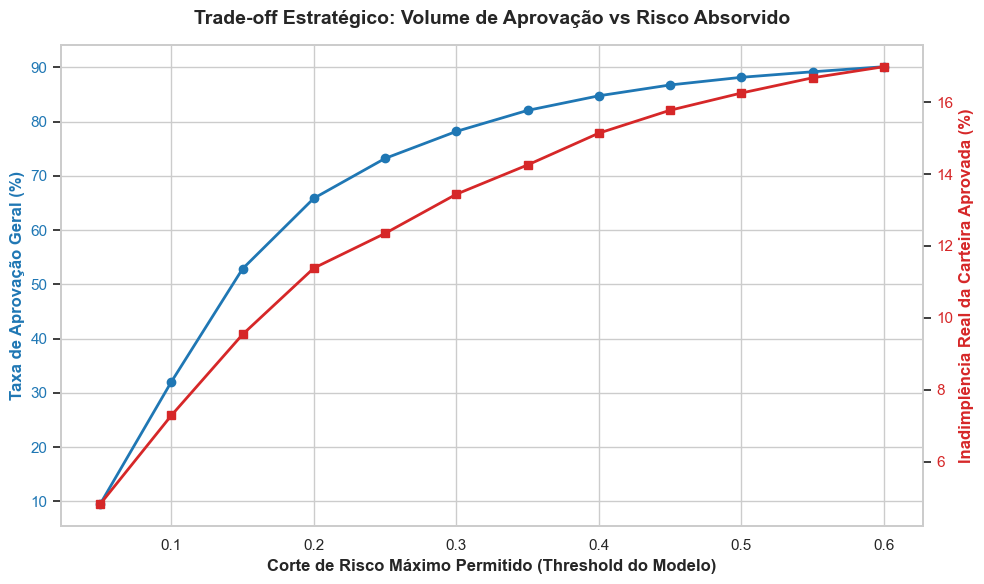

In [9]:
# ==============================================================================
# 4. VISUALIZAÇÃO 1: TRADE-OFF DE APROVAÇÃO
# ==============================================================================
print(">>> Gerando painel de trade-off (volume vs risco)...")

fig, ax1 = plt.subplots(figsize=(10, 6))

# Eixo Y esquerdo (volume)
color1 = '#1f77b4'
ax1.plot(df_results['Max_Risk_Cutoff'], df_results['Approval_Rate'], color=color1, marker='o', lw=2)
ax1.set_xlabel('Corte de Risco Máximo Permitido (Threshold do Modelo)', fontweight='bold')
ax1.set_ylabel('Taxa de Aprovação Geral (%)', color=color1, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_title('Trade-off Estratégico: Volume de Aprovação vs Risco Absorvido', fontweight='bold', fontsize=14, pad=15)

# Eixo Y direito (qualidade/risco)
ax2 = ax1.twinx()
color2 = '#d62728'
ax2.plot(df_results['Max_Risk_Cutoff'], df_results['Portfolio_Default_Rate'], color=color2, marker='s', lw=2)
ax2.set_ylabel('Inadimplência Real da Carteira Aprovada (%)', color=color2, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color2)

plt.grid(False) # Desativa a grade secundária para não poluir

# Exportação e exibição
plt.tight_layout()
plt.savefig('../assets/img/tradeoff_approval_risk.png', dpi=300, bbox_inches='tight', facecolor='white')
print("✅ Gráfico gerado e salvo com sucesso!\n")
plt.show()

# Maximização de lucro

A curva de rentabilidade cruza os dados do modelo com os parâmetros financeiros para determinar a política de crédito exata que a instituição deve adotar.

>>> Calculando o ponto de lucro máximo e extraindo insights de negócio...
✅ Gráfico gerado e salvo com sucesso!



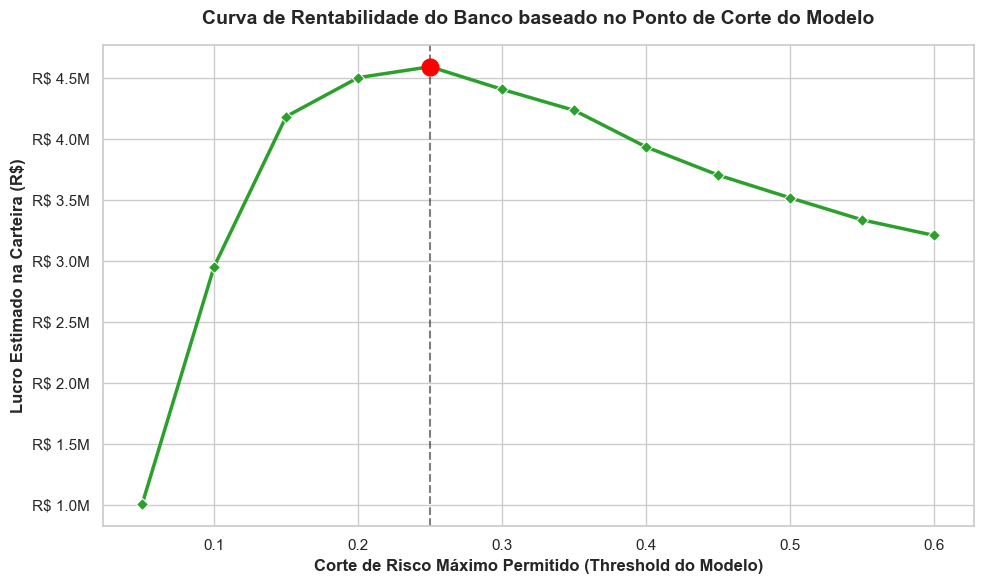


 RELATÓRIO EXECUTIVO DE IMPACTO DE NEGÓCIO
Lucro máximo simulado: R$ 4,595,500.00
Política de crédito ótima: aprovar clientes com risco predito menor que 25%
Impacto no volume: aprovação de 73.2% das propostas de cartão.
Controle de risco: a inadimplência real interna ficará contida em 12.4%.



In [10]:
# ==============================================================================
# 5. VISUALIZAÇÃO 2: A CURVA DE LUCRO
# ==============================================================================
print(">>> Calculando o ponto de lucro máximo e extraindo insights de negócio...")

# Encontra o ponto exato de lucro máximo
max_profit_point = df_results.loc[df_results['Estimated_Profit_BRL'].idxmax()]

plt.figure(figsize=(10, 6))
sns.lineplot(data=df_results, x='Max_Risk_Cutoff', y='Estimated_Profit_BRL', color='#2ca02c', marker='D', lw=2.5)

# Destaca o ponto ótimo no gráfico
plt.axvline(max_profit_point['Max_Risk_Cutoff'], color='black', linestyle='--', alpha=0.5)
plt.plot(max_profit_point['Max_Risk_Cutoff'], max_profit_point['Estimated_Profit_BRL'], marker='o', markersize=12, color='red')

plt.title('Curva de Rentabilidade do Banco baseado no Ponto de Corte do Modelo', fontweight='bold', fontsize=14, pad=15)
plt.xlabel('Corte de Risco Máximo Permitido (Threshold do Modelo)', fontweight='bold')
plt.ylabel('Lucro Estimado na Carteira (R$)', fontweight='bold')

# Formata o eixo Y para mostrar em milhões de reais
formatter = ticker.FuncFormatter(lambda x, pos: f'R$ {x*1e-6:.1f}M')
plt.gca().yaxis.set_major_formatter(formatter)

# Exportação e exibição
plt.tight_layout()
plt.savefig('../assets/img/profit_maximization_curve.png', dpi=300, bbox_inches='tight', facecolor='white')
print("✅ Gráfico gerado e salvo com sucesso!\n")
plt.show()

# ==============================================================================
# 6. RELATÓRIO EXECUTIVO
# ==============================================================================
print("\n" + "="*60)
print(" RELATÓRIO EXECUTIVO DE IMPACTO DE NEGÓCIO")
print("="*60)
print(f"Lucro máximo simulado: R$ {max_profit_point['Estimated_Profit_BRL']:,.2f}")
print(f"Política de crédito ótima: aprovar clientes com risco predito menor que {max_profit_point['Max_Risk_Cutoff']*100:.0f}%")
print(f"Impacto no volume: aprovação de {max_profit_point['Approval_Rate']:.1f}% das propostas de cartão.")
print(f"Controle de risco: a inadimplência real interna ficará contida em {max_profit_point['Portfolio_Default_Rate']:.1f}%.")
print("="*60 + "\n")